<a href="https://colab.research.google.com/github/hemanthrayal/ipl-data-analysis-python/blob/main/Copy_of_case_study_on_ipl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IPL Data Analysis using Python

This project analyzes IPL match data to extract insights about team performance,
toss impact, player achievements, and match distribution using Python libraries
like Pandas and Matplotlib.

---



In [4]:
import pandas as pd
ipl_data=pd.read_csv("matches.csv")


## Dataset Overview

The dataset contains information about IPL matches such as season,
teams, toss winner, match winner, venue, and player of the match.

In [5]:
ipl_data.head(5)

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [6]:
ipl_data.shape
ipl_data.columns
ipl_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [7]:
#Statistical summary
ipl_data.describe()

,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [8]:
#Find how many matches were played in each season.
ipl_data.groupby("season")["date"].count()

,date
season,
2007/08,58
2009,57
2009/10,60
2011,73
2012,74
2013,76
2014,60
2015,59
2016,60


In [9]:
#Which team has won the most IPL matches
ipl_data["winner"].value_counts().sort_values(ascending=False)


,count
winner,
Mumbai Indians,144
Chennai Super Kings,138
Kolkata Knight Riders,131
Royal Challengers Bangalore,116
Rajasthan Royals,112
Sunrisers Hyderabad,88
Kings XI Punjab,88
Delhi Daredevils,67
Delhi Capitals,48


In [10]:
#Find which stadium hosted the most IPL matches
idx=ipl_data.groupby("venue")["id"].count().idxmax()
idx

'Eden Gardens'

In [11]:
#How many matches were won by the team that also won the toss.
ipl_data[ipl_data["toss_winner"]==ipl_data["winner"]].shape[0]

554

In [12]:
#Which player has won the most "Player of the Match" awards.
ipl_data["player_of_match"].value_counts().idxmax()

'AB de Villiers'

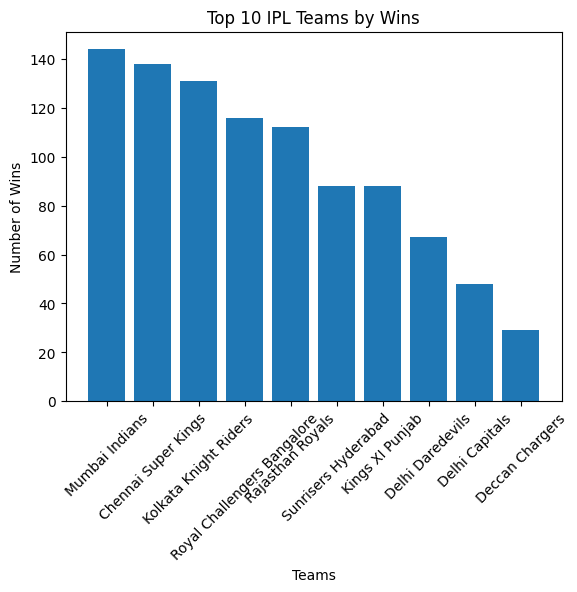

In [13]:
#Create a bar chart showing the top 10 teams with the most IPL wins using the winner column.
import matplotlib.pyplot as plt

# Count wins per team
team_wins = ipl_data["winner"].value_counts().head(10)

# Plot bar chart
plt.bar(team_wins.index, team_wins.values)

# Labels and title
plt.xlabel("Teams")
plt.ylabel("Number of Wins")
plt.title("Top 10 IPL Teams by Wins")

# Rotate team names for readability
plt.xticks(rotation=45)

# Show the graph
plt.show()

In [14]:
ipl_data.loc[:,["toss_winner","toss_decision"]]

,toss_winner,toss_decision
0,Royal Challengers Bangalore,field
1,Chennai Super Kings,bat
2,Rajasthan Royals,bat
3,Mumbai Indians,bat
4,Deccan Chargers,bat
...,...,...
1090,Punjab Kings,bat
1091,Sunrisers Hyderabad,bat
1092,Rajasthan Royals,field
1093,Rajasthan Royals,field


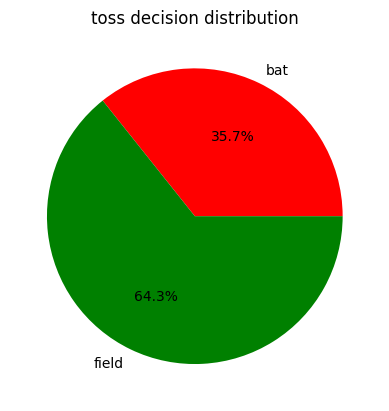

In [15]:
#Create a pie chart showing toss decision distribution:
toss_des=ipl_data.groupby("toss_decision")["toss_winner"].count()
labels=toss_des.index
values=toss_des.values
colors=["red","green"]
plt.pie(values,labels=labels,colors=colors,autopct="%1.1f%%")
plt.title("toss decision distribution")
plt.show()


In [16]:
#Which team won the most tosses in IPL history.
ipl_data["toss_winner"].value_counts().idxmax()

'Mumbai Indians'

In [17]:
#Find the win percentage of teams that win the toss.
(ipl_data[ipl_data["toss_winner"]==ipl_data["winner"]].shape[0])/(ipl_data["id"].count())*100


np.float64(50.593607305936075)

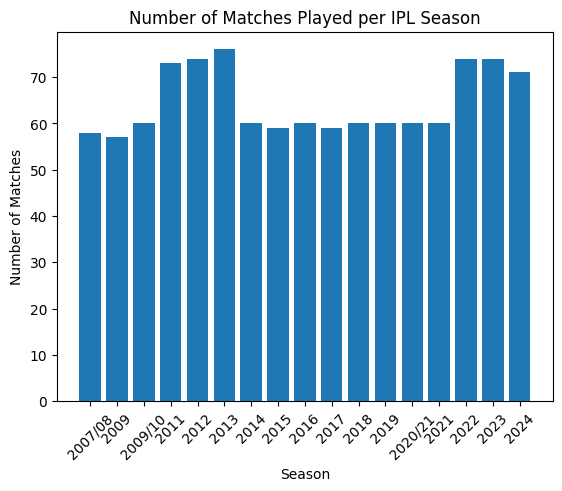

In [18]:
#Matches Played per Season (Bar Chart)
import matplotlib.pyplot as plt

season_matches = ipl_data["season"].value_counts().sort_index()

plt.bar(season_matches.index, season_matches.values)

plt.xlabel("Season")
plt.ylabel("Number of Matches")
plt.title("Number of Matches Played per IPL Season")
plt.xticks(rotation=45)
plt.show()

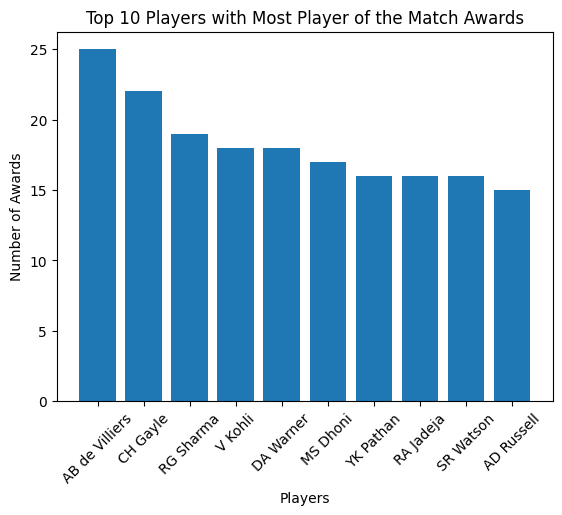

In [19]:
#Top 10 Players with Most Player of the Match Awards
top_players = ipl_data["player_of_match"].value_counts().head(10)

plt.bar(top_players.index, top_players.values)

plt.xticks(rotation=45)

plt.xlabel("Players")
plt.ylabel("Number of Awards")
plt.title("Top 10 Players with Most Player of the Match Awards")

plt.show()

## Key Insights

1. Teams that win the toss win approximately 50–55% of matches.
2. Mumbai Indians and Chennai Super Kings have the highest number of wins.
3. Players like AB de Villiers dominate Player of the Match awards.
4. Most teams prefer fielding first after winning the toss.

#Data Cleaning







Data Cleaning and Preprocessing

Before performing further analysis, the dataset is checked for missing
values and unnecessary columns to ensure the quality and reliability
of the analysis.

In [20]:
#check missing values in each column
ipl_data.isna().sum()

,0
id,0
season,0
city,51
date,0
match_type,0
player_of_match,5
venue,0
team1,0
team2,0
toss_winner,0


In [21]:
#duplicate rows exist in the dataset.
ipl_data.duplicated().sum()

np.int64(0)

In [22]:
#unique values in the column toss_decision
ipl_data['toss_decision'].unique()

array(['field', 'bat'], dtype=object)

In [23]:
#how many times each toss decision occurs
ipl_data["toss_decision"].value_counts()

,count
toss_decision,
field,704
bat,391


In [24]:
#how many unique teams appear in the dataset
len(ipl_data["team1"].unique())

19

In [25]:
#Handle Missing Values
ipl_data["city"].fillna("Unknown", inplace=True)
ipl_data["winner"].fillna("No Result", inplace=True)
ipl_data["player_of_match"].fillna("Unknown", inplace=True)

/tmp/ipykernel_164/2464651208.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  ipl_data["city"].fillna("Unknown", inplace=True)
/tmp/ipykernel_164/2464651208.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [26]:
#Drop Irrelevant Columns
ipl_data = ipl_data.drop(columns=["method", "umpire1", "umpire2"], errors="ignore")

In [27]:
#Verify the Cleaned Dataset
ipl_data.isnull().sum()

,0
id,0
season,0
city,0
date,0
match_type,0
player_of_match,0
venue,0
team1,0
team2,0
toss_winner,0


Handling Missing Values

Some columns such as target_runs, target_overs, and result_margin
contain missing values because they are conditionally applicable.

For example:
- target_runs and target_overs appear only when a team is chasing.
- result_margin depends on whether the win was by runs or wickets.

Therefore, these missing values are expected and are not treated
as data errors.

# Advanced Match Analysis

This section performs deeper analysis on IPL matches to understand
patterns between toss results, match outcomes, and team strategies.

In [28]:
#Which teams benefit the most from winning the toss?
data=ipl_data[ipl_data["toss_winner"]==ipl_data["winner"]]
data["winner"].value_counts()

,count
winner,
Mumbai Indians,78
Chennai Super Kings,75
Kolkata Knight Riders,68
Rajasthan Royals,60
Royal Challengers Bangalore,57
Sunrisers Hyderabad,38
Kings XI Punjab,36
Delhi Daredevils,35
Delhi Capitals,26


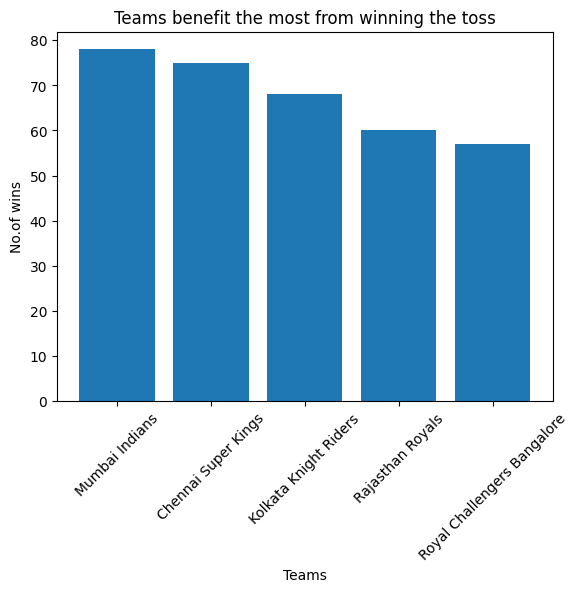

In [29]:
data1=data["winner"].value_counts().head(5)

plt.bar(data1.index,data1.values)
plt.xticks(rotation=45)
plt.title("Teams benefit the most from winning the toss")
plt.xlabel("Teams")
plt.ylabel("No.of wins")
plt.show()


Insight

The analysis shows that certain teams benefit more from winning
the toss. Teams such as Mumbai Indians and Chennai Super Kings
appear frequently among the top teams, indicating that toss
advantage can sometimes influence match outcomes.

#Venue Advantage Analysis
Venue Advantage AnalysisDifferent stadiums host IPL matches under varying pitch and weatherconditions. This analysis identifies the venues that have hosted thehighest number of IPL matches.

In [30]:
#Counting  how many matches were played at each venue

#Selecting the top 5 venues

#Storing the result in a variable (for plotting next)

ven=ipl_data["venue"].value_counts().head(5)
ven

,count
venue,
Eden Gardens,77
Wankhede Stadium,73
M Chinnaswamy Stadium,65
Feroz Shah Kotla,60
"Rajiv Gandhi International Stadium, Uppal",49


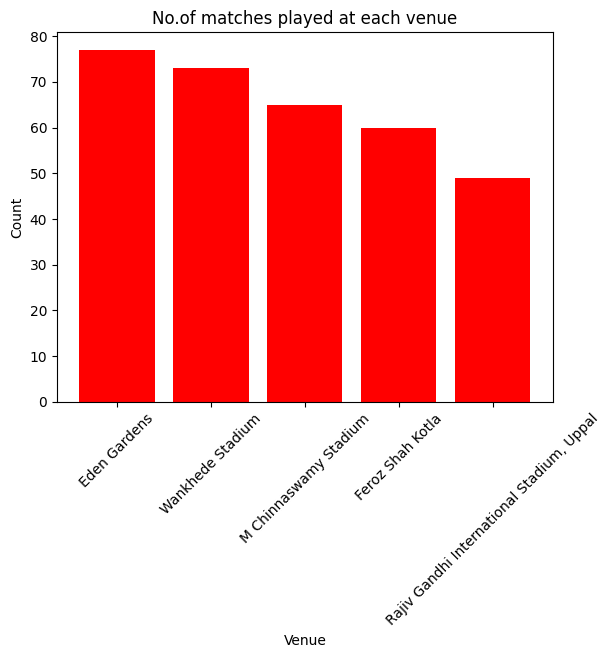

In [31]:
plt.bar(ven.index,ven.values,color="red")
plt.xticks(rotation=45)
plt.title("No.of matches played at each venue")
plt.xlabel("Venue")
plt.ylabel("Count")
plt.show()

#Insight

The analysis shows that certain venues host a significantly higher
number of IPL matches. Stadiums such as Eden Gardens and
Wankhade Stadium appear among the most frequently used venues,
indicating their importance in hosting IPL matches.

#Toss Decision Strategy

This analysis examines whether teams prefer batting or fielding
after winning the toss. Understanding this preference helps reveal
common strategic choices made by teams in IPL matches.

# Conclusion


Conclusion:

This project performed an exploratory analysis of the IPL matches dataset
to understand patterns in team performance, toss decisions, venues, and
player achievements.

The analysis showed that some teams benefit more from winning the toss,
certain stadiums host a large number of IPL matches, and teams often prefer
fielding after winning the toss.

Using Python libraries such as Pandas and Matplotlib, the dataset was
cleaned, analyzed, and visualized to extract meaningful insights about IPL
match trends.

This project demonstrates how data analysis techniques can be applied to
sports datasets to discover useful patterns and support better
decision-making.